## Librerias

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, spearmanr, chi2_contingency


from sklearn.preprocessing import PowerTransformer

from sklearn.feature_selection import mutual_info_classif

Lectura de los datos

In [2]:
df_raw = pd.read_csv("../data/framingham.csv")

In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [4]:
df_raw.shape

(4240, 16)

In [5]:
df_raw.head(7)

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
5,0,43,2.0,0,0.0,0.0,0,1,0,228.0,180.0,110.0,30.30,77.0,99.0,0
6,0,63,1.0,0,0.0,0.0,0,0,0,205.0,138.0,71.0,33.11,60.0,85.0,1


In [6]:
#Comprobamos cuantos nulos tiene
df_raw.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

Antes de empezar con el EDA, voy a declarar las variables que están codificadas como categóricas, para que tenga sentido las gráficas.

In [7]:
df= df_raw.copy()
categoricas = ['male', 'education', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'TenYearCHD']
df[categoricas] = df[categoricas].astype('object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   object 
 1   age              4240 non-null   int64  
 2   education        4135 non-null   object 
 3   currentSmoker    4240 non-null   object 
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   object 
 6   prevalentStroke  4240 non-null   object 
 7   prevalentHyp     4240 non-null   object 
 8   diabetes         4240 non-null   object 
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   object 
dtypes: float64(7), int64(1), object(8)
memory usage: 530.1+ KB


In [9]:
numeric_cols = df.select_dtypes(exclude= 'object').columns.tolist()
str_cols = df.select_dtypes(include ='object').columns.tolist()
print(numeric_cols)
print("-----------------")
print(str_cols)

['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
-----------------
['male', 'education', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'TenYearCHD']


Vamo a ver los estadísticos principales, para ver como primera interacción los datos. Podemos observar: que posiblemente haya outliers en las siguientes columnas (totChol, diaBP,sispBP ,hearRate y glucose,etc).

In [10]:
df.describe(percentiles=[.25,.5,.75,.95,.99]).T

,count,mean,std,min,25%,50%,75%,95%,99%,max
age,4240.0,49.580189,8.572942,32.00,42.00,49.0,56.00,64.000,67.000,70.0
cigsPerDay,4211.0,9.005937,11.922462,0.00,0.00,0.0,20.00,30.000,43.000,70.0
totChol,4190.0,236.699523,44.591284,107.00,206.00,234.0,263.00,312.000,354.110,696.0
sysBP,4240.0,132.354599,22.033300,83.50,117.00,128.0,144.00,175.000,200.000,295.0
diaBP,4240.0,82.897759,11.910394,48.00,75.00,82.0,90.00,104.525,118.000,142.5
BMI,4221.0,25.800801,4.079840,15.54,23.07,25.4,28.04,32.780,38.956,56.8
heartRate,4239.0,75.878981,12.025348,44.00,68.00,75.0,83.00,98.000,110.000,143.0
glucose,3852.0,81.963655,23.954335,40.00,71.00,78.0,87.00,108.450,174.960,394.0


In [11]:
#Ver estadísticos principales de cada variable, para saber cuantos valores únicos tienen, cual es el más frecuente, etc.
df.describe(include=object).T

,count,unique,top,freq
male,4240.0,2.0,0.0,2420.0
education,4135.0,4.0,1.0,1720.0
currentSmoker,4240.0,2.0,0.0,2145.0
BPMeds,4187.0,2.0,0.0,4063.0
prevalentStroke,4240.0,2.0,0.0,4215.0
prevalentHyp,4240.0,2.0,0.0,2923.0
diabetes,4240.0,2.0,0.0,4131.0
TenYearCHD,4240.0,2.0,0.0,3596.0


Vemos el peso que tienen en el dataset de si se ha desarrollado o no. Vemos claramente que la target está desbalanceada, a un 15,2% de personas enfermas y un 84,8% aprox de personas que no se han enfermado

In [12]:
df['TenYearCHD'].value_counts(normalize=True)*100

TenYearCHD
0    84.811321
1    15.188679
Name: proportion, dtype: float64

## Análisis Univariable

**Columnas Categóricas**

Observamos las distribuciones de cada una de las variables numéricas y a priori podemos ver que hay outliers como hemos dicho previamente y que las distribuciones parecen ser mas o menos normales, excepto en algunas variables como por ejemplo: cigsperDay. Pasos que voy a seguir:

1. **cigsperDay**: para normalizar su distribución podría probar con el método de BoxCox para ver si corrige un poco hacia la distribución normal. Y al ser todos los valores mayores que 0, creo que podríamos hacerlo.
2. **Tratamiento de los nulos** : En los nulos que no vemos de manera clara la distribución, vamos a implementar las siguientes estrategias:
- **glucose** la estrategia que vamos a implementar es la de transformarlo a logaritmo, para que los outliers tengan mucho menos impacto e intentar ver la distribución de manera más clara.

Observamos a primera vista que hay muchas columnas presentan asimetría (skewness), ya que hay distribuciones que tienen una cola de outliers muy para la derecha. Por ejemplo: Heart Rate. Y para el resto las distribuciones se ven bastante normales, con algunos outliers, que podríamos usar la estandarización, para las variables como por ejemplo: totCHol, sysBP,etc.


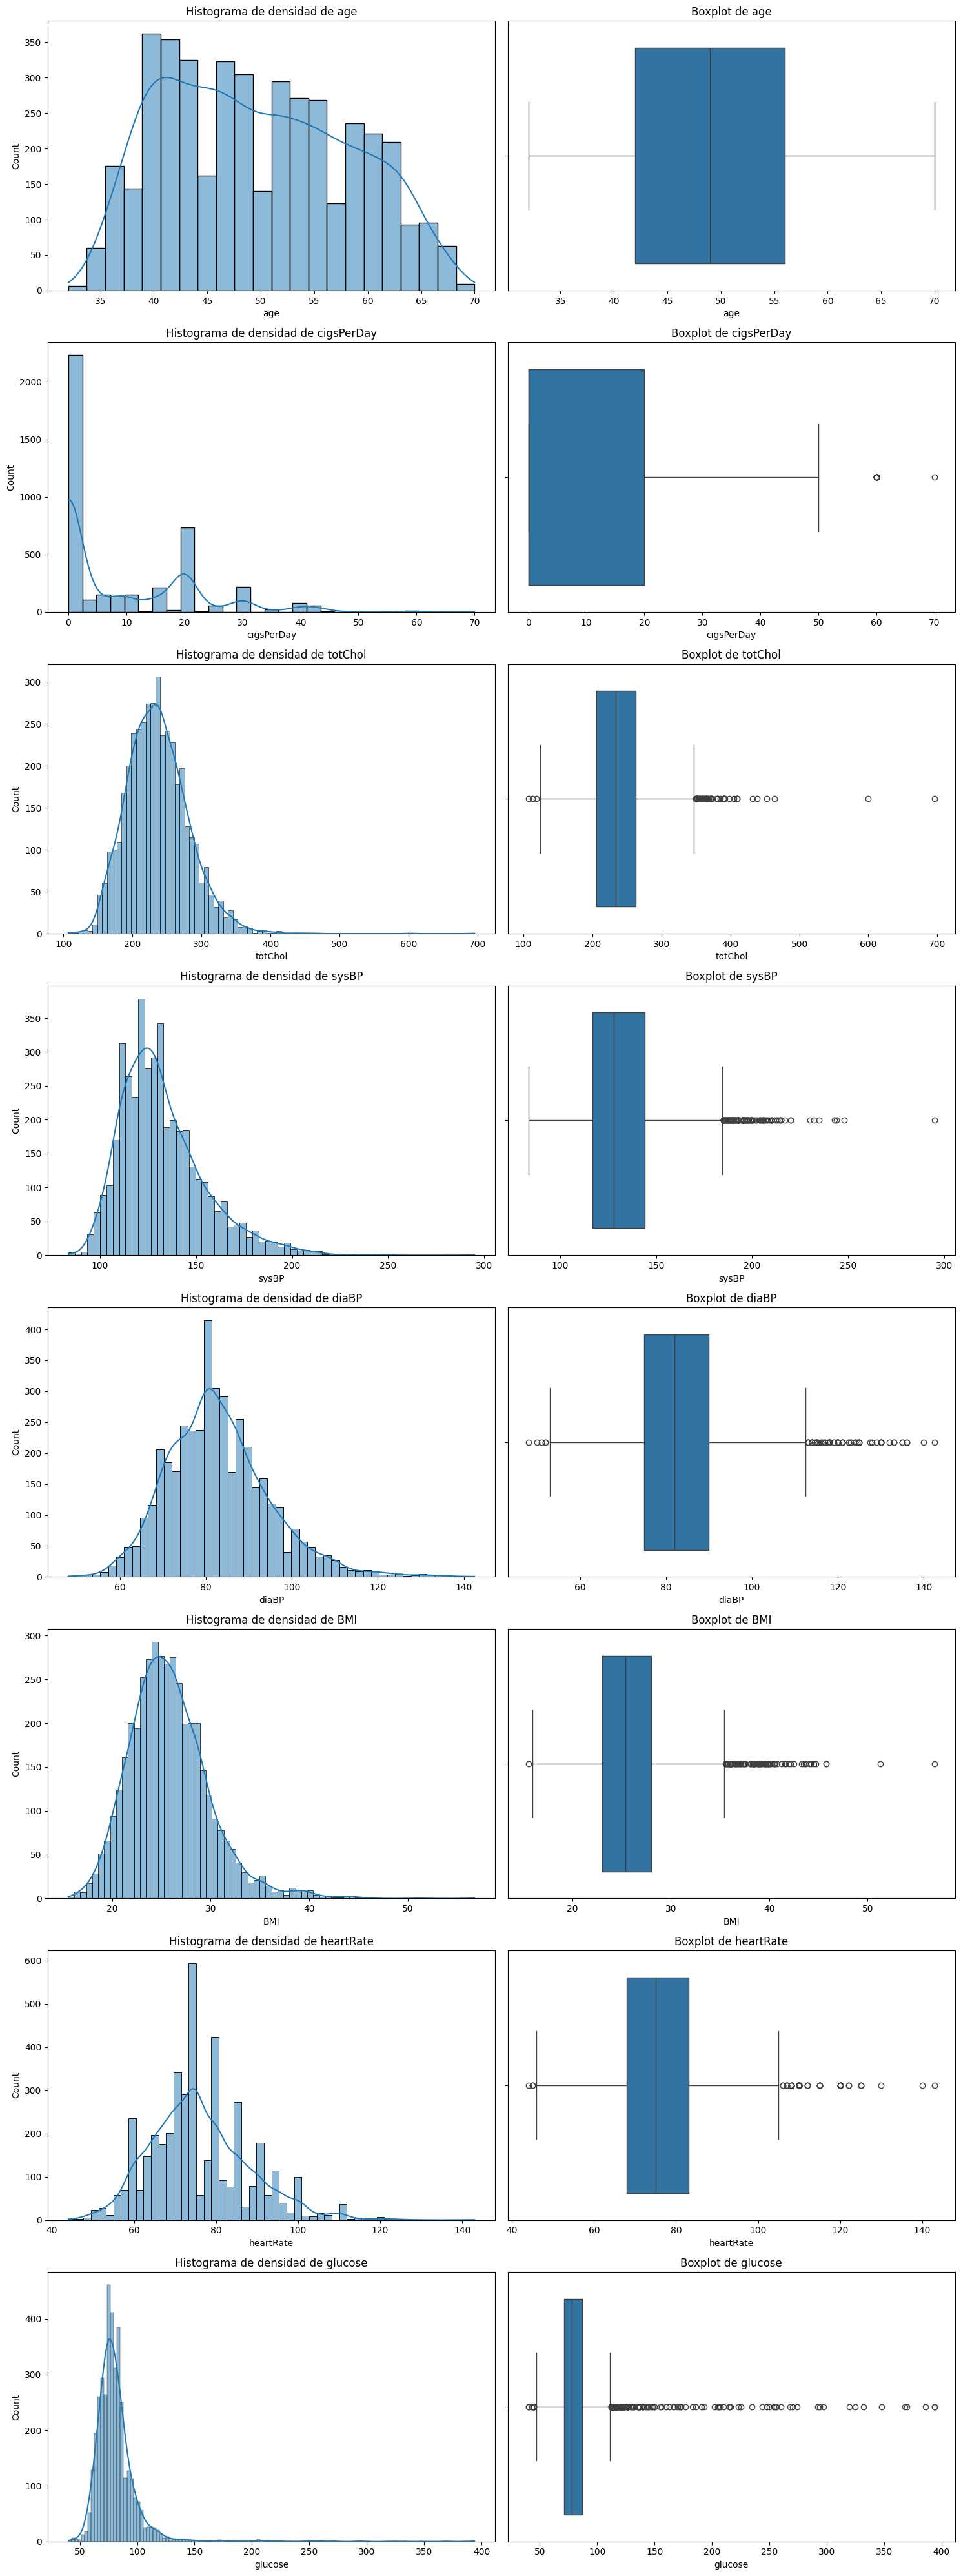

In [ ]:
nrows = len(numeric_cols)
fig, axes = plt.subplots(nrows= nrows, ncols=2, figsize=(15, 5*nrows))

for i, column in enumerate(df_raw[numeric_cols]):
    # i = índice (0,1,2,3,4)  | column es lo mismo solo que para usarlo de diferente manera.
    #Histograma de densidad
    sns.histplot(df_raw[column],kde = True, ax=axes[i,0]) 
        # kde=True --> Dibuja una linea sobre las barras que ayuda a ver la "forma" de los datos.
        # ax=axes[i,0] --> Dibuja el histograma en la fila i, columna 0 (la izquierda).
    axes[i, 0].set_title(f'Histograma de densidad de {column}')

    #Boxplot
    sns.boxplot(x=df_raw[column], ax=axes[i,1])
    axes[i,1].set_title(f"Boxplot de {column}")

plt.tight_layout()
plt.show()

Observamos el porcentaje de los outliers y observamos que no son muchos, por lo que algunas columnas en el que se vean bien la distirbución normal, no las vamos a tratar en el EDA.

In [37]:
print("--- Resumen de Outliers ---")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    perc = (len(outliers) / len(df)) * 100
    print(f"{col}: {len(outliers)} registros ({perc:.2f}%)")

--- Resumen de Outliers ---
age: 0 registros (0.00%)
cigsPerDay: 12 registros (0.28%)
totChol: 56 registros (1.32%)
sysBP: 126 registros (2.97%)
diaBP: 77 registros (1.82%)
BMI: 97 registros (2.29%)
heartRate: 76 registros (1.79%)
glucose: 188 registros (4.43%)


**BoxCox**

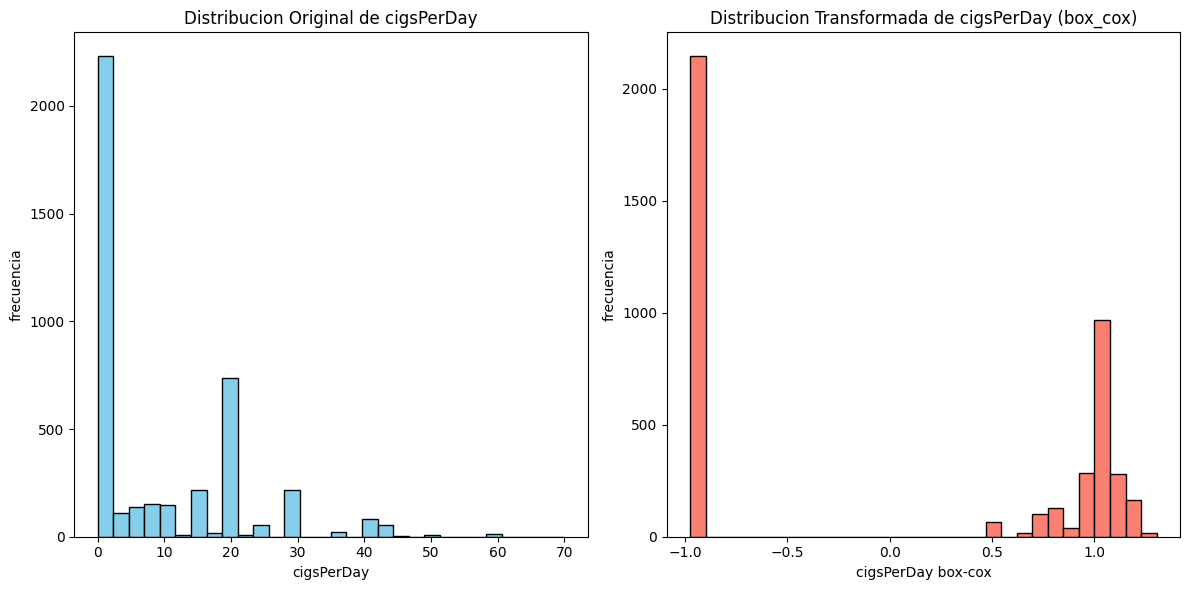

In [43]:
pt=PowerTransformer(method="box-cox")
df['cigsPerDay_Box']=pt.fit_transform(df[["cigsPerDay"]]+0.001) #el +0.001 porque necesitamos extrictamente valores positivos

plt.figure(figsize=(12,6))

#histograma de la distribucion original de "fare"
plt.subplot(1,2,1)
plt.hist(df['cigsPerDay'],bins=30,color="skyblue",edgecolor="k")
plt.title("Distribucion Original de cigsPerDay")
plt.xlabel("cigsPerDay")
plt.ylabel("frecuencia")

#histograma de la distribucion transformada de "fare_box-cox"
plt.subplot(1,2,2)
plt.hist(df['cigsPerDay_Box'],bins=30,color="salmon",edgecolor="k")
plt.title("Distribucion Transformada de cigsPerDay (box_cox)")
plt.xlabel("cigsPerDay box-cox")
plt.ylabel("frecuencia")

plt.tight_layout()
plt.show()

Aqui vemos claramente la brecha entre los que no fuman y los que fuman, ha normalizado a los que fuman, en cambio, es obvio que los que no fuman están alejados de la distribución normal y en este caso se puede ver claramente que los no fumadoores son la gran mayoría de las personas.

**Logaritmo**

In [39]:
df["glucose_log"]=np.log1p(df["glucose"])

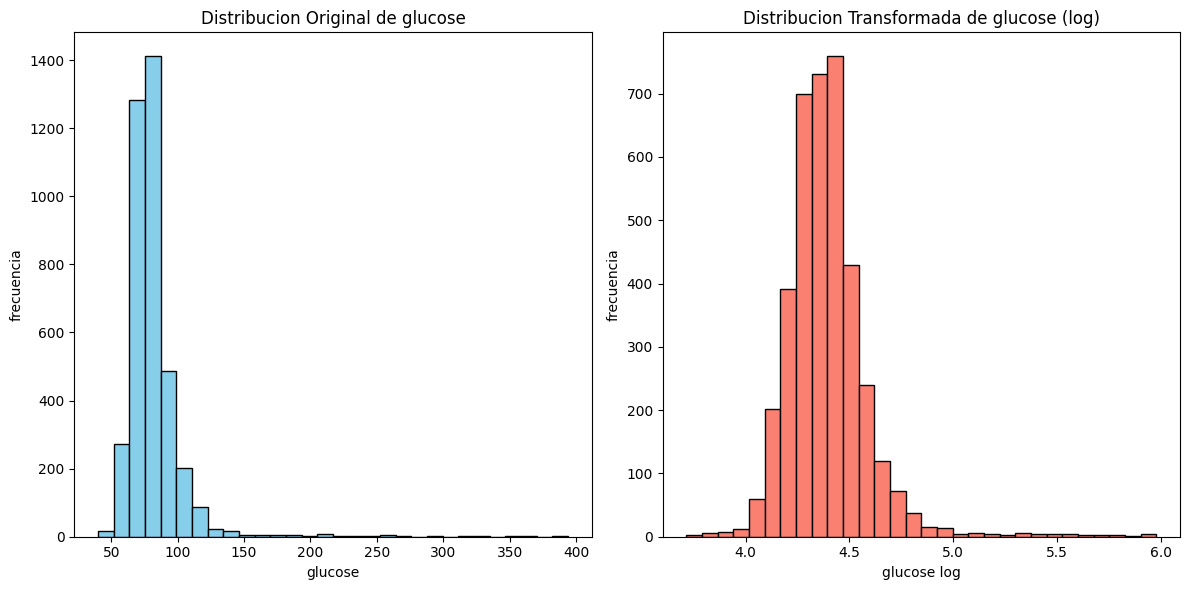

In [44]:
plt.figure(figsize=(12,6))

#histograma de la distribucion original de "fare"
plt.subplot(1,2,1)
plt.hist(df["glucose"],bins=30,color="skyblue",edgecolor="k")
plt.title("Distribucion Original de glucose")
plt.xlabel("glucose")
plt.ylabel("frecuencia")

#histograma de la distribucion transformada de "fare_robust"
plt.subplot(1,2,2)
plt.hist(df["glucose_log"],bins=30,color="salmon",edgecolor="k")
plt.title("Distribucion Transformada de glucose (log)")
plt.xlabel("glucose log")
plt.ylabel("frecuencia")

plt.tight_layout()
plt.show()

Observamos que ha mejorado la vista de la distribución y el logaritmo ha hecho que el impacto de los outliers sea mucho menor. Por lo que en el preprocessing se podría implementar el logaritmo.

Una vez hecho esto observamos el histograma y el boxplot de nuevo de estas dos variables.

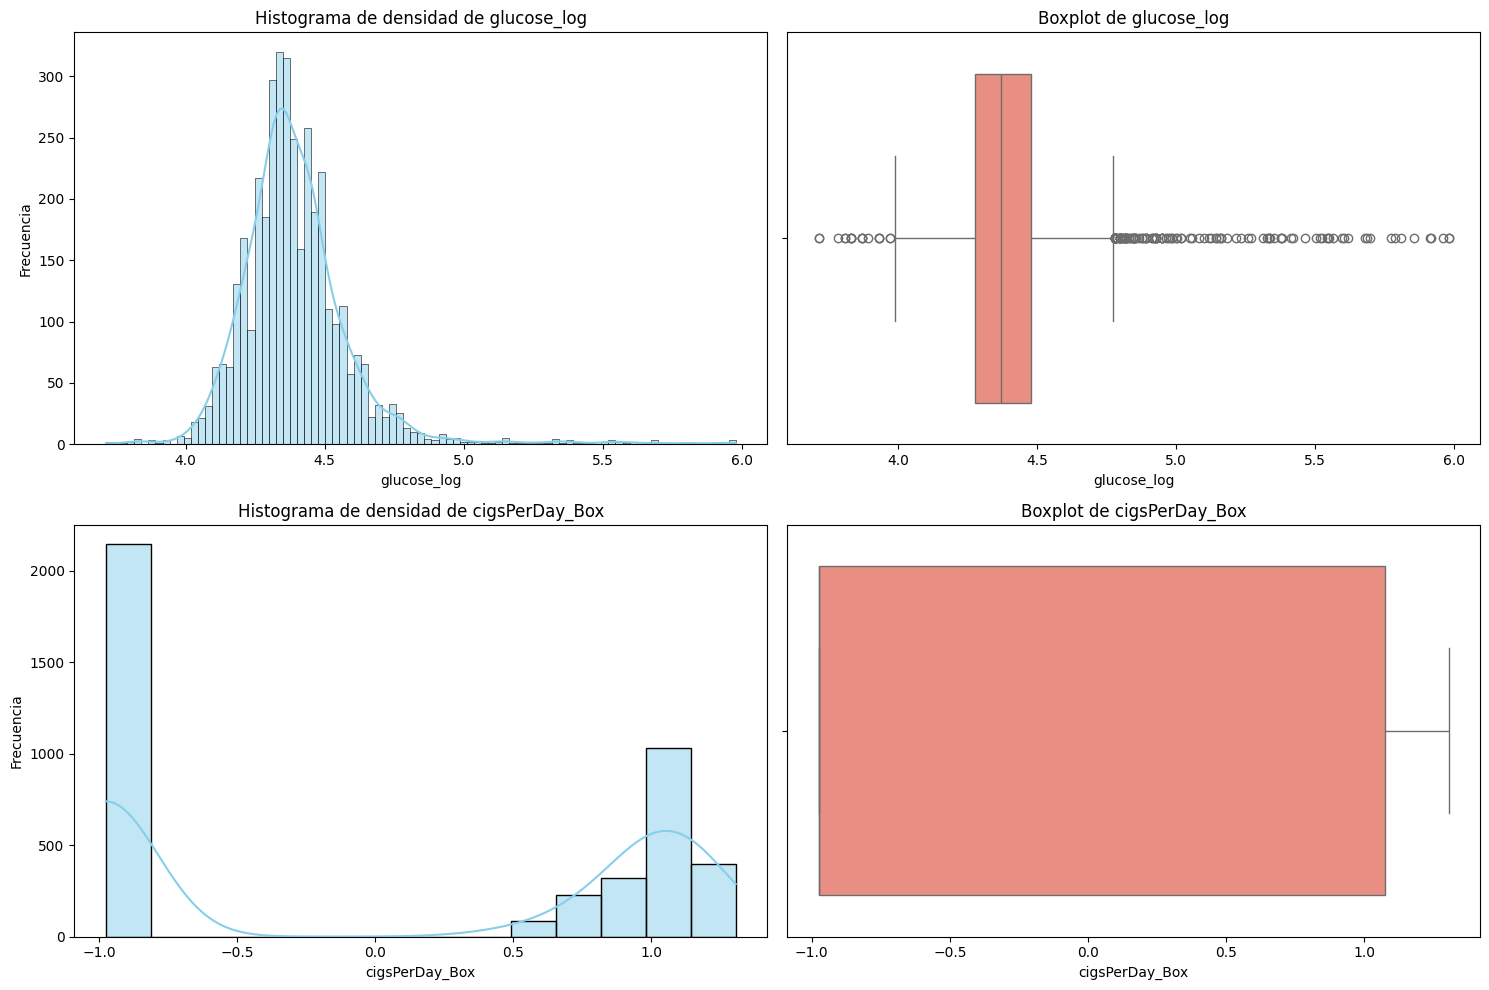

In [47]:
#Codigo corregido por la IA

cols_cambiados = ['glucose_log', 'cigsPerDay_Box']

nrows = len(cols_cambiados) # Dinámico, por si luego añades más columnas
fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=(15, 5*nrows))

for i, column in enumerate(cols_cambiados):
    # 1. Histograma de densidad (Izquierda)
    # CORRECCIÓN: Usamos df[column] para seleccionar solo la columna actual
    sns.histplot(df[column], kde=True, ax=axes[i,0], color="skyblue") 
    axes[i, 0].set_title(f'Histograma de densidad de {column}')
    axes[i, 0].set_xlabel(column)
    axes[i, 0].set_ylabel('Frecuencia')

    # 2. Boxplot (Derecha)
    # CORRECCIÓN: Usamos x=df[column]
    sns.boxplot(x=df[column], ax=axes[i,1], color="salmon")
    axes[i,1].set_title(f"Boxplot de {column}")
    axes[i,1].set_xlabel(column)

plt.tight_layout()
plt.show()

Aqui verificamos dos cosas:
1. El logaritmo para la variable **glucose** ha sido acertada, ya que al haber tantos outliers, impedía la visualización de la distribución al máximo. Es decir, que con la implementación del logaritmo podemos ver la distribución normal de manera más clara.
2. El BoxCox para la variable de **cigsPerDay** también ha sido una decisión acertada, ya que podemos ver la distribución más normal, a pesar de que podemos ver una brecha enorme en la izquierda, esto se debe a que como he dicho anteriormente, hay mucha gente que no es fumadora.
3. Los outliers no podemos eliminarlos ya que al estar tratando de casos relacionados a medicina, los outliers son casos especiales e importantes.

**Columnas Categóricas**

Una vez terminado las columnas numéricas, vamos a observar las distribuciones de las columnas categóricas.

C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_7628\3847560513.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index, ax=axs[i], palette="viridis")
C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_7628\3847560513.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index, ax=axs[i], palette="viridis")
C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_7628\3847560513.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, o

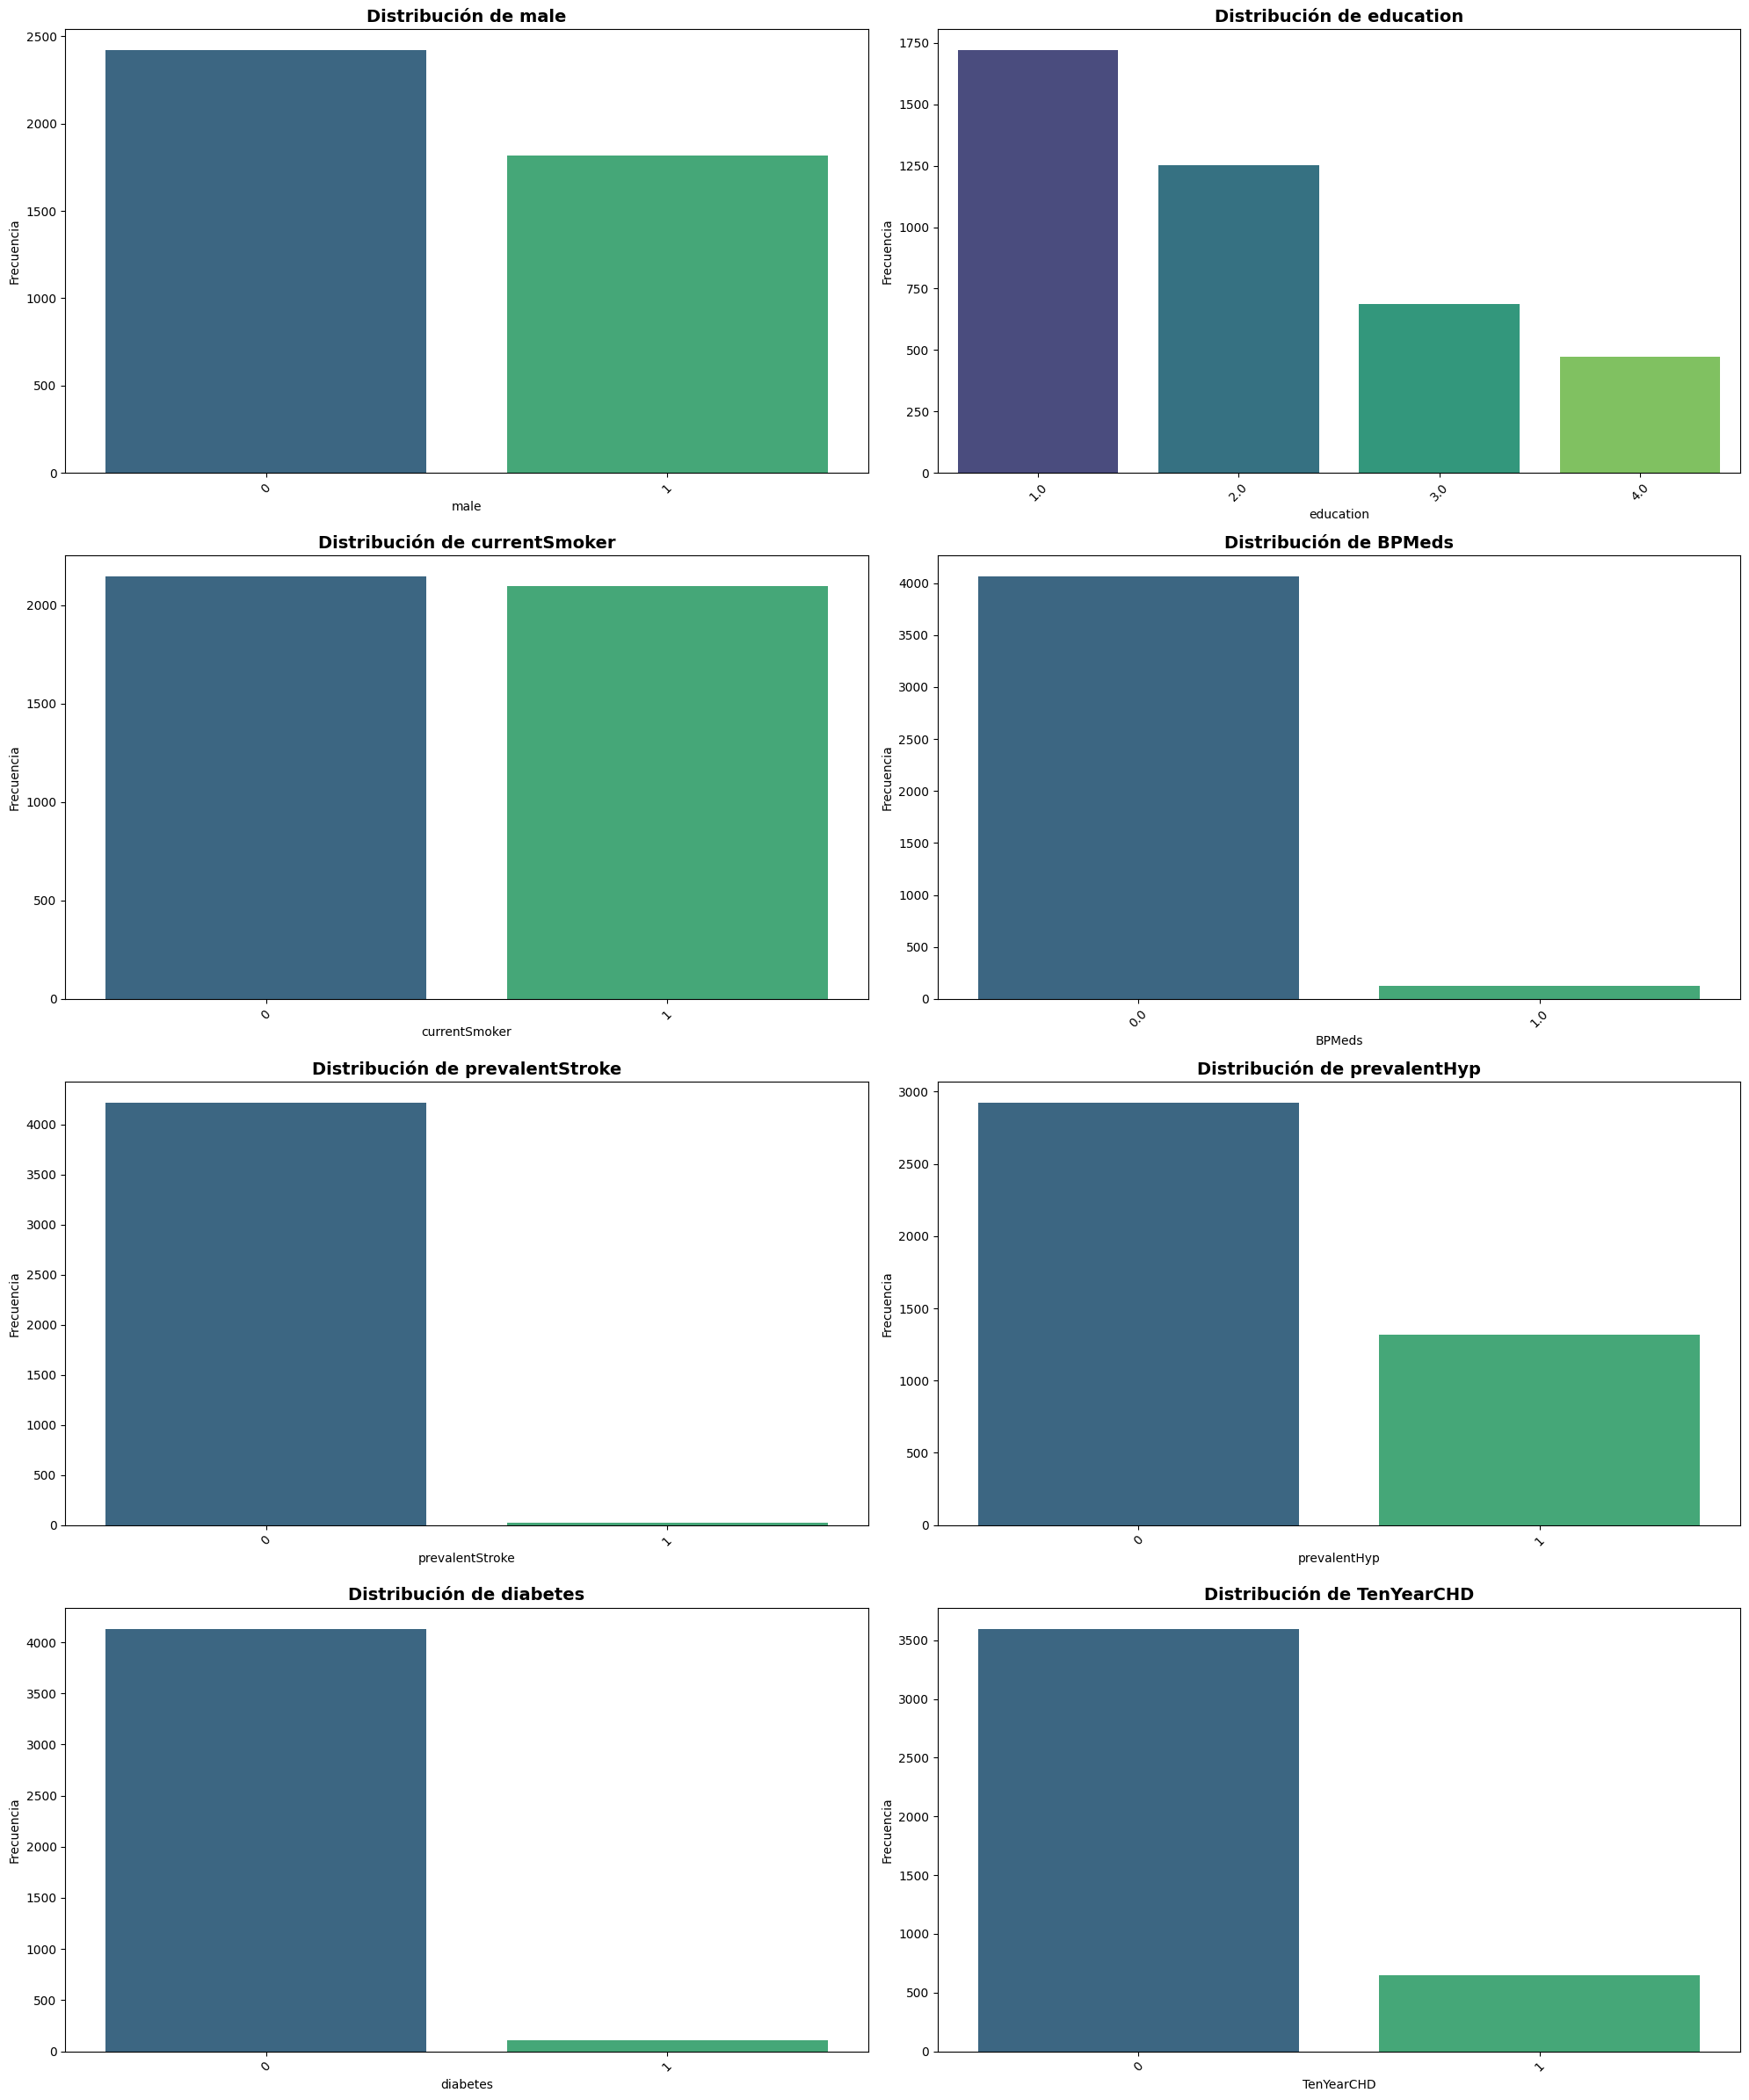

In [52]:
#No me funcionaba el código y Error corregido por IA

import math

# Asegúrate de que str_cols tenga solo las columnas que quieres graficar
# str_cols = ['col1', 'col2', 'col3', 'col4', 'col5'] 

# 1. Calculamos las filas necesarias para tener 2 columnas siempre
n_cols_grafico = 2
nrows = math.ceil(len(str_cols) / n_cols_grafico)

# 2. Creamos la figura
fig, axs = plt.subplots(nrows=nrows, ncols=n_cols_grafico, figsize=(20, 6 * nrows))

# 3. Aplanamos los ejes para iterar linealmente
axs = axs.flatten()

for i, col in enumerate(str_cols):
    # Ahora i nunca será mayor que el tamaño de axs
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, ax=axs[i], palette="viridis")
    
    axs[i].set_title(f'Distribución de {col}', fontsize=14, fontweight='bold')
    axs[i].set_xlabel(col)
    axs[i].set_ylabel('Frecuencia')
    
    # Rotación dinámica
    num_categorias = df[col].nunique()
    axs[i].tick_params(axis='x', rotation=90 if num_categorias > 10 else 45)

# 4. Limpieza de subplots sobrantes
# Si tienes 5 columnas, subplots crea 6 espacios (3x2). Borramos el sexto.
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

En las columnas categóricas, observamos que hay muchas variables que tienen una diferencia de pesos enorme, es decir, que en el dataset tenemos más datos de gente de sexo femenino que positivo por ejemplo, o la variable de diabetes se ve que la gran mayoría de las personas no tienen diabetes y un porcentaje muy pequeño si. Además, también hay columnas que la frecuencia es bastante similar (currentsmoker). Es decir, que hay muchas variables que están desbalanceadas.

## Análisis Bivariado

Una vez conocido a fondo las variables del dataset. Vamos a entrar más a fondo, en el análisis bivariado planteandonos una serie de hipótesis para ver si realmente hay características que afecten a desarrollar una enfermedad en 10 años, es decir, nuestra variable target (TenYearCHD). Hipótesis: 
1. ¿La gente fumadora tiene más riesgo de desarrollar una enfermedad? (currentSmoker y cigsPerDay)
2. ¿Tienen más riesgo de desarrollar una enfermedad las personas que han sufrido ictus previamente? (prevalentStroke)
3. ¿Tienen más facilidd de desarrollar una enfermedad las personas que tienen diabetes? (diabetes,glucose)
3. ¿Se espera que a mayor edad, mayor sea el riesgo de desarrollar enfermedad coronaria? (age)
4. Se hipotetiza que los hombres tienen una mayor probabilidad de desarrollar en comparación con las mujeres. (male)
5. Se espera que el nivel educativo, cuanto menos estudios tengas más probabilidad de riesgo de sufrir tienes. (education.)
6. Existe una correlación positiva fuerte entre la presión sistólica alta y el riesgo a 10 años. (sysBP, prevalentHyp)
7. Se espera que un IMC elevado se asocie con mayor riesgo, pero quizás mediado por la hipertensión y la diabetes (BMI)

Todos los gráficos van a estar hechos con ayuda de IA.

C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_7628\2844900582.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='currentSmoker', y=target, ax=axes[0], palette='viridis', capsize=.1)
C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_7628\2844900582.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['No Fumador', 'Fumador'])
C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_7628\2844900582.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_fumadores, x=target, y='cigsPerDay', ax=axes[1], palette='magma')
C:\Users\alejandrofan\AppData\Local\Temp\ipykerne

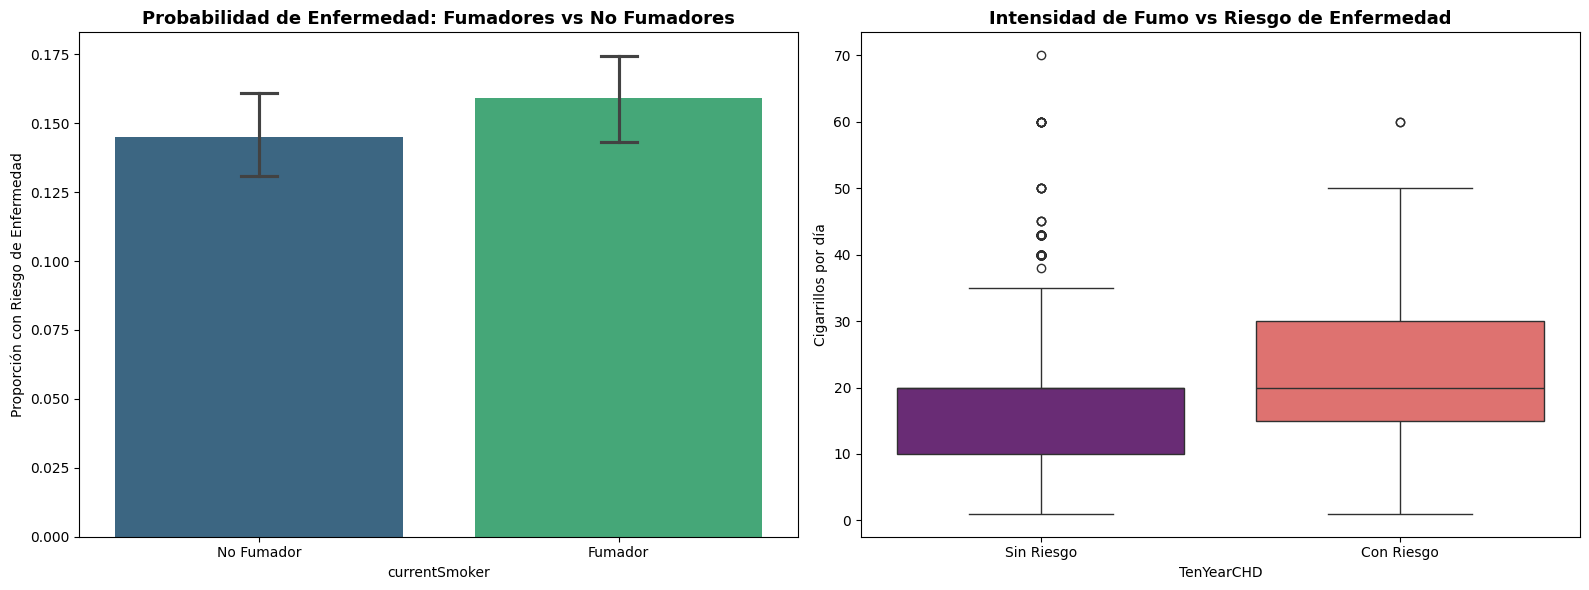

In [55]:
# Suponiendo que tu variable objetivo es 'TenYearCHD' (Enfermedad Coronaria)
# Si tiene otro nombre en tu dataset, cámbiala aquí:
target = 'TenYearCHD' 

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Proporción de enfermedad según si es fumador actual
# Este gráfico muestra el porcentaje de riesgo en fumadores vs no fumadores
sns.barplot(data=df, x='currentSmoker', y=target, ax=axes[0], palette='viridis', capsize=.1)
axes[0].set_title('Probabilidad de Enfermedad: Fumadores vs No Fumadores', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Proporción con Riesgo de Enfermedad')
axes[0].set_xticklabels(['No Fumador', 'Fumador'])

# Gráfico 2: Relación entre cantidad de cigarrillos y enfermedad
# Usamos un Boxplot para ver si los que enferman (1) fuman más que los que no (0)
# Filtramos solo a los fumadores (>0) para que el "muro de ceros" no rompa el gráfico
df_fumadores = df[df['cigsPerDay'] > 0]
sns.boxplot(data=df_fumadores, x=target, y='cigsPerDay', ax=axes[1], palette='magma')
axes[1].set_title('Intensidad de Fumo vs Riesgo de Enfermedad', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(['Sin Riesgo', 'Con Riesgo'])
axes[1].set_ylabel('Cigarrillos por día')

plt.tight_layout()
plt.show()

1. Respuesta: Aqui observamos que las personas fumadoras tienen más probabilidad de desarrollar una enfermedad, aunque la diferencia no es muy grande (no fumador un poco menos del 15 % y los fumadores tienen una probabilidad de 16 % aproximadamente de sufrir.) La diferencia de estas dos es del 2% mas o menos. Aunque la diferencia es muy similar, como estamos hablando de salud, de enfermades esta diferencia puede darse de mucho importancia. Una vez visto que las personas fumadoras son las que más probabilidad tienen de desarrollar una enfermedad, vemos un boxplot de personas que tienen riesgo a enfermarse y no riesgo a enfermarse. En este boxplot vemos claramente que aquellas personas que se han enfermado han fumado muchos cigarillos al día que aquellas personas que no tienen riesgo. Resumiendo, las personas que fuman tienen más riesgo de sufrir enfermedades, y claramente se ve en la mediana de las personas con riesgo, una mediana de 20 cigarrillos por día. 
Por lo que las personas que fuman mucho al día sí que tienen mayor riesgo a sufrir enfermedades en 10 años.

C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_7628\2603206261.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='prevalentStroke', y=target, ax=ax, palette='coolwarm', capsize=.1)
C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_7628\2603206261.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Sin Ictus Previo', 'Con Ictus Previo'])


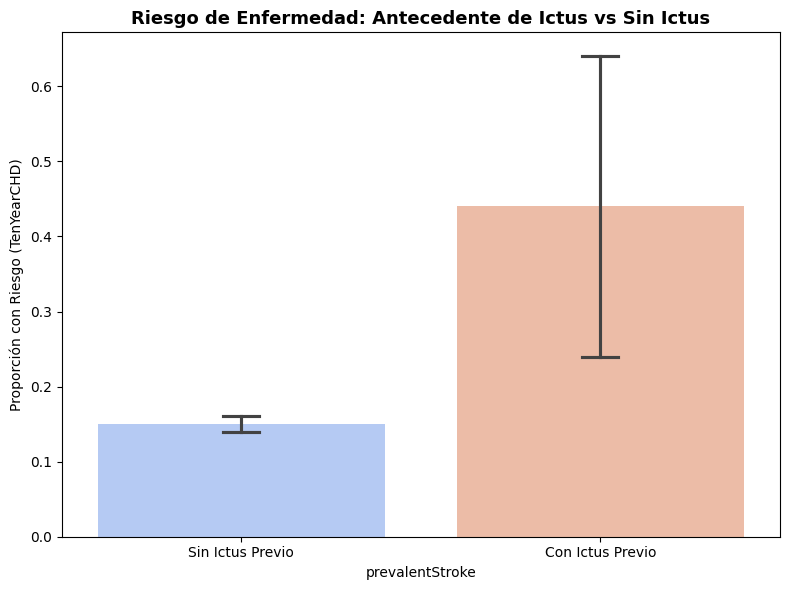

In [59]:
target = 'TenYearCHD'

# Cambiamos axes[0] por axes simplemente
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

sns.barplot(data=df, x='prevalentStroke', y=target, ax=ax, palette='coolwarm', capsize=.1)
ax.set_title('Riesgo de Enfermedad: Antecedente de Ictus vs Sin Ictus', fontsize=13, fontweight='bold')
ax.set_xticklabels(['Sin Ictus Previo', 'Con Ictus Previo'])
ax.set_ylabel('Proporción con Riesgo (TenYearCHD)')

plt.tight_layout()
plt.show()

2. Respuesta: En el primer gráfico, podemos observar claramente que aquellas personas que sufrieron un ictus previamente han tenido enfermedades en 10 años, y la diferencia es bastante grande. Un 15%% de probabilidad de aquellas personas que no tuvieron ictus y un 45% aprox de personas que sufrieron ictus previo. Esto puede ser porque el sistema inmune al haber sufrido ya previamente una enfermedad, esa persona tiene mayor riesgo a sufrirla de nuevo, por lo que la diferencia es bastante grande. Resumiendo, una persona que ha sufrido ictus previo, si que tienen más probabilidad de sufrir una enfermedad en el futuro.

C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_7628\3619741053.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='diabetes', y=target, ax=axes[0], palette='magma', capsize=.1)
C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_7628\3619741053.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['No Diabético', 'Diabético'])
C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_7628\3619741053.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['No Diabético', 'Diabético'])


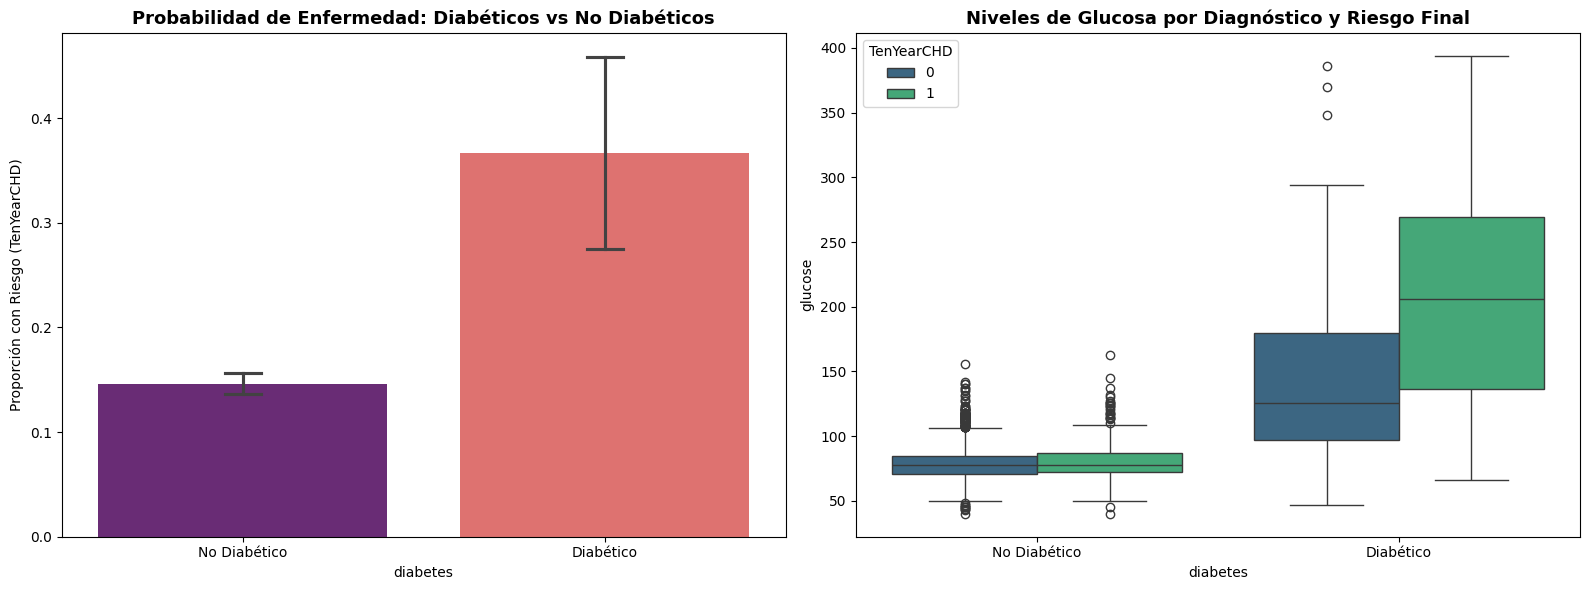

In [63]:
target = 'TenYearCHD'

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Proporción de riesgo según diagnóstico de diabetes
sns.barplot(data=df, x='diabetes', y=target, ax=axes[0], palette='magma', capsize=.1)
axes[0].set_title('Probabilidad de Enfermedad: Diabéticos vs No Diabéticos', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(['No Diabético', 'Diabético'])
axes[0].set_ylabel('Proporción con Riesgo (TenYearCHD)')

# Gráfico 2: Glucosa vs Riesgo (Boxplot para ver la diferencia de niveles)
sns.boxplot(data=df, x='diabetes', y='glucose', hue=target, ax=axes[1], palette='viridis')
axes[1].set_title('Niveles de Glucosa por Diagnóstico y Riesgo Final', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(['No Diabético', 'Diabético'])


plt.tight_layout()
plt.show()

3. Respuesta: Claramente se puede ver que aquellas personas que sufren diabetes tienen más riesgo a sufrir una enfermedad en el futuro, se ve claramente tanto en el gráfico de barras como en el boxplot. Esto quiere decir que las personas que tienen un nivel de glucosa muy elevado tienen muchas más probabilidades de sufrir enfermedades, hablando aproximadamente de una mediana de 220 de nivel de glucosa. Por lo que, aceptamos la hipótesis de que las personas diabéticas tienen riesgo a enfermedades.

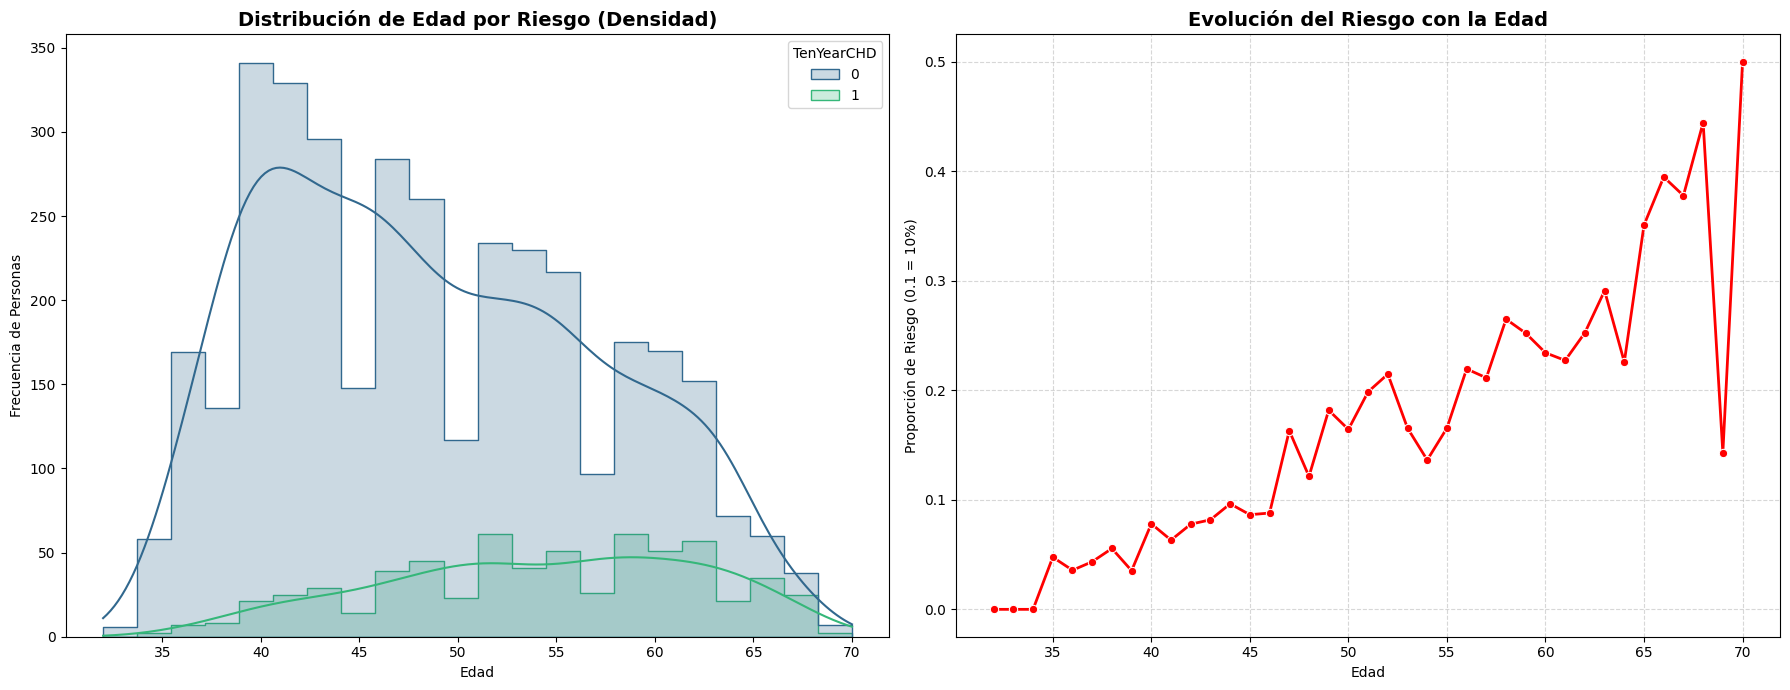

In [65]:
target = 'TenYearCHD'

# Configuramos 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- GRÁFICO 1 (Izquierda): Histograma de Densidad ---
# Nos permite ver cuánta gente hay de cada edad y cuántos están en riesgo
sns.histplot(data=df, x='age', hue=target, kde=True, element="step", ax=axes[0], palette='viridis')
axes[0].set_title('Distribución de Edad por Riesgo (Densidad)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Frecuencia de Personas')

# --- GRÁFICO 2 (Derecha): Línea de Probabilidad Media ---
# Calculamos la probabilidad real por cada año de vida
prob_por_edad = df.groupby('age')[target].mean()
sns.lineplot(x=prob_por_edad.index, y=prob_por_edad.values, ax=axes[1], color='red', marker='o', linewidth=2)
axes[1].set_title('Evolución del Riesgo con la Edad', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Proporción de Riesgo (0.1 = 10%)')
axes[1].set_xlabel('Edad')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

4. En la gráfica de la izquierda, observamos que la curva de las personas sanas decae mucho más rápido que el de las personas con riesgo a medida que la edad aumenta, esto se debe a que es mucho más dificil encontrar personas mayores de 60 que no tengan ningún nivel de riesgo detectado. En cuanto a la gráfica de la derecha, observamos que los jóvenes entre 30-45 años el riesgo es bajo y estable y ya a partir de los 45 años empieza a subir bastante y de manera bastante rápida. Por lo que sí, aceptamos la hipótesis de que a medida que la edad va aumentando mayor riesgo de sufrir una enfermedad.

C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_7628\3421483706.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='male', y=target, ax=ax, palette='pastel', capsize=.1)
C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_7628\3421483706.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Mujer', 'Hombre'])


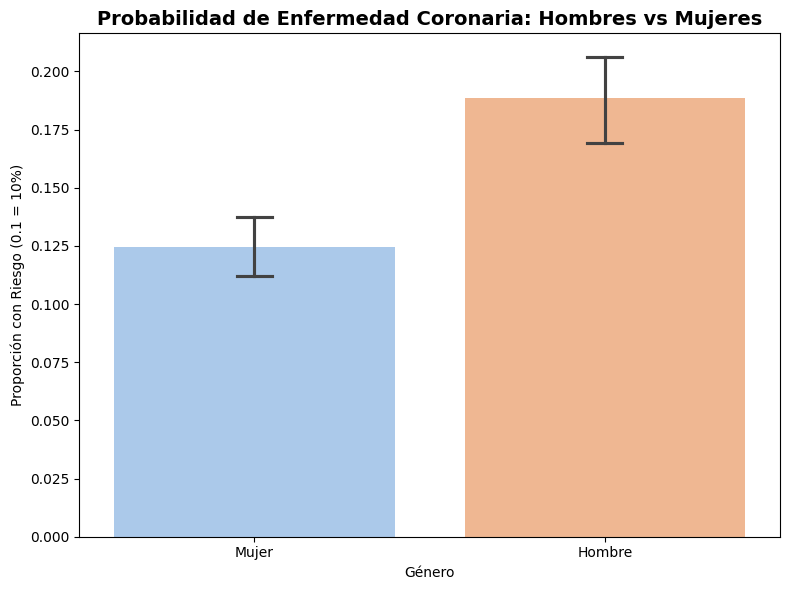

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

target = 'TenYearCHD'

# Configuramos 1 solo gráfico (1 fila, 1 columna)
fig, ax = plt.subplots(figsize=(8, 6))

# Gráfico de barras directo
sns.barplot(data=df, x='male', y=target, ax=ax, palette='pastel', capsize=.1)

# Estética y etiquetas
ax.set_title('Probabilidad de Enfermedad Coronaria: Hombres vs Mujeres', fontsize=14, fontweight='bold')
ax.set_xticklabels(['Mujer', 'Hombre'])
ax.set_ylabel('Proporción con Riesgo (0.1 = 10%)')
ax.set_xlabel('Género')

plt.tight_layout()
plt.show()

4. Aceptamos la hipótesis, ya que vemos claramente que el género sí que afecta al riesgo de sufrir una enfermedad, especialmente para los hombres con un 18,5% aprox y un 12,5% de sufrir para la mujer.

C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_7628\2026993179.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='education', y=target, ax=ax, palette='viridis', capsize=.1)


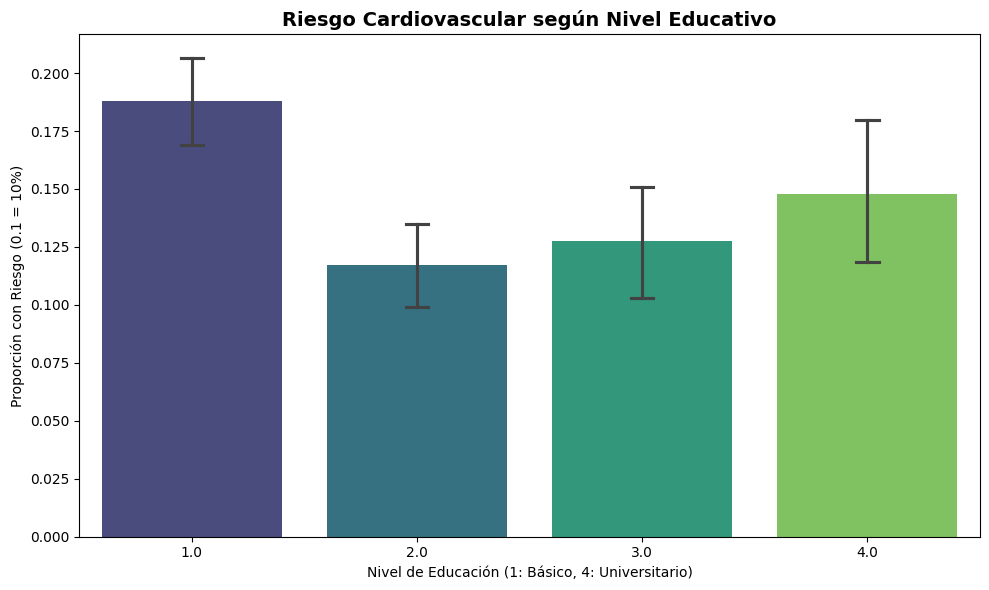

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

target = 'TenYearCHD'

# Configuramos 1 solo gráfico
fig, ax = plt.subplots(figsize=(10, 6))

# Gráfico de barras para observar la tendencia según el nivel educativo
sns.barplot(data=df, x='education', y=target, ax=ax, palette='viridis', capsize=.1)

# Estética y etiquetas
ax.set_title('Riesgo Cardiovascular según Nivel Educativo', fontsize=14, fontweight='bold')
ax.set_xlabel('Nivel de Educación (1: Básico, 4: Universitario)')
ax.set_ylabel('Proporción con Riesgo (0.1 = 10%)')

plt.tight_layout()
plt.show()


5. Observamos que a medida que se va elevando el nivel de educación la probabilidad de riesgo baja es menor, es decir que la diferencia entre aquellas personas que tienen una educación básica tienen más riesgo de sufrir una enfermedad. Teniendo un 18,5% en el nivel basico de educación, y el resto de variables de educación menor que 15% de probabilidad de riesgo de sufrir una enfermedad. Por lo que aceptamos la hipótesis.

C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_7628\1053467728.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Sin Hipertensión Previa', 'Con Hipertensión Previa'])


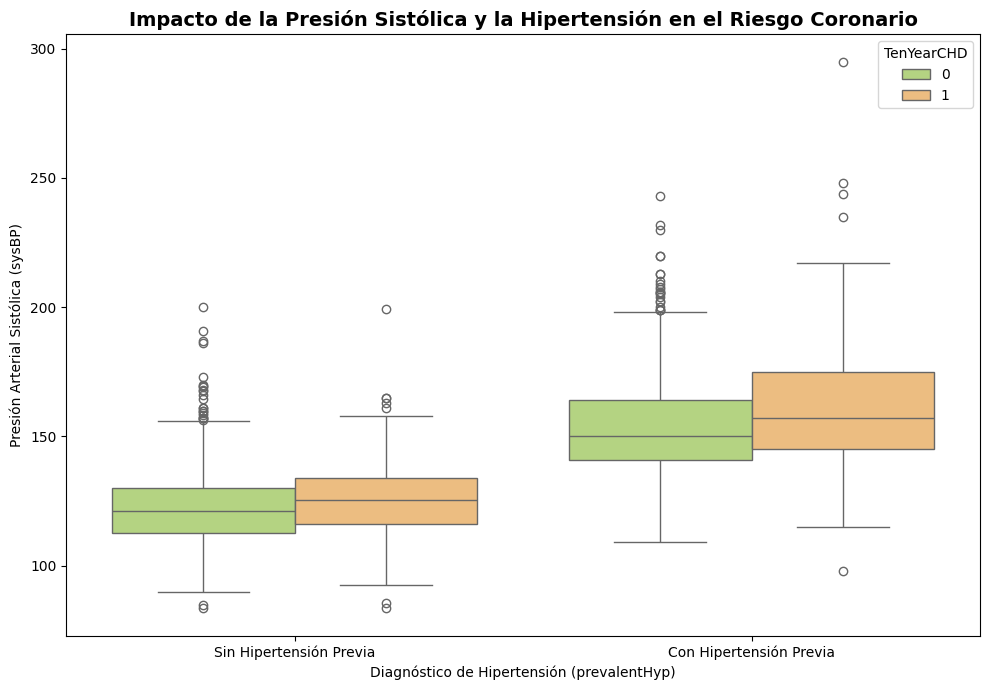

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

target = 'TenYearCHD'

# Configuramos la figura
fig, ax = plt.subplots(figsize=(10, 7))

# Gráfico de cajas: Relación entre Presión Sistólica, Hipertensión y Riesgo Final
sns.boxplot(data=df, x='prevalentHyp', y='sysBP', hue=target, palette='RdYlGn_r', ax=ax)

# Estética
ax.set_title('Impacto de la Presión Sistólica y la Hipertensión en el Riesgo Coronario', fontsize=14, fontweight='bold')
ax.set_xticklabels(['Sin Hipertensión Previa', 'Con Hipertensión Previa'])
ax.set_xlabel('Diagnóstico de Hipertensión (prevalentHyp)')
ax.set_ylabel('Presión Arterial Sistólica (sysBP)')

plt.tight_layout()
plt.show()

6. Observamos que una persona con hipertensión o no, la probabilidad de que tener riesgo a una enfermedad es mas alta, ay que como bien se ven el gráfico las personas que tienen una presion arterial mayor sufren. Además observamos que las medianas están similares tanto en hipertensión como sin hipertensión, es decir, se asemejan mucho. Por lo que podemos ver que puede existir una correlación fuerte con nuestra target, que confirmaremos mucho más adelante con las correlaciones.


7. Se espera que un IMC elevado se asocie con mayor riesgo, pero quizás mediado por la hipertensión y la diabetes (BMI)

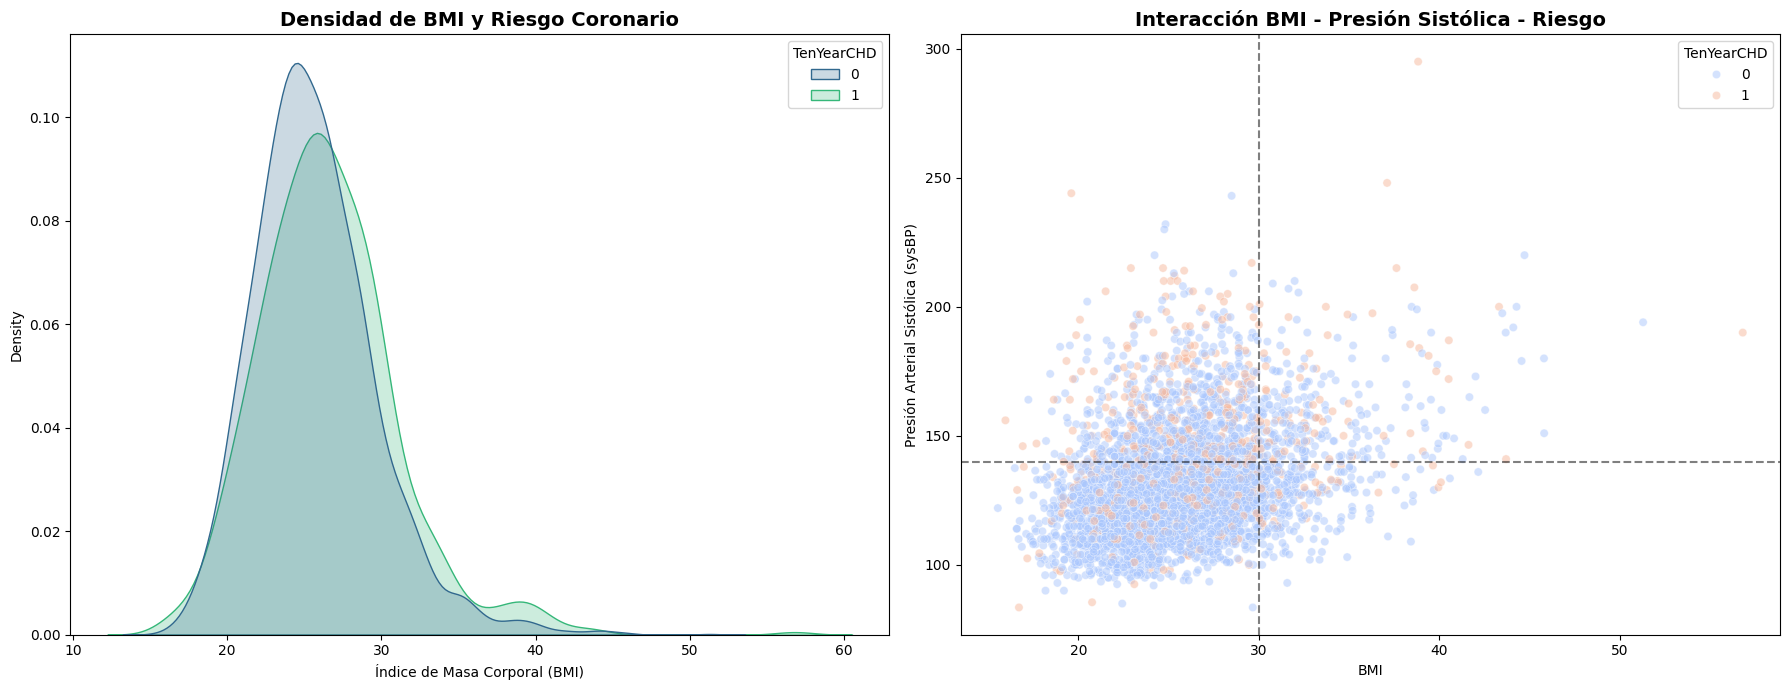

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

target = 'TenYearCHD'

# Configuramos 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- GRÁFICO 1 (Izquierda): Distribución de BMI según Riesgo ---
sns.kdeplot(data=df, x='BMI', hue=target, fill=True, common_norm=False, palette='viridis', ax=axes[0])
axes[0].set_title('Densidad de BMI y Riesgo Coronario', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Índice de Masa Corporal (BMI)')

# --- GRÁFICO 2 (Derecha): BMI vs Presión Sistólica (Mediación) ---
# Usamos el color para el riesgo y el tamaño para ver la relación
sns.scatterplot(data=df, x='BMI', y='sysBP', hue=target, alpha=0.5, palette='coolwarm', ax=axes[1])
axes[1].set_title('Interacción BMI - Presión Sistólica - Riesgo', fontsize=14, fontweight='bold')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Presión Arterial Sistólica (sysBP)')
# Añadimos líneas de referencia clínica (BMI 30 = Obesidad, sysBP 140 = Hipertensión)
axes[1].axvline(30, color='black', linestyle='--', alpha=0.5)
axes[1].axhline(140, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

7. Observamos que el índice de masa corporal no tiene una relación tan directa a nuestra target, ya que se asemejan bastante, por lo que no puedo aceptar del todo que la variable BMI esté tan asociada a la target ya que la diferencia es relativamente poca. Sin embargo, en el gráfico de la derecha, observamos que a medida que la BMI crece, la presión sistólica sube también y observamos que la gran mayoría de los puntos son personas que no tienen riesgo. Por lo que esta hipótesis no la podemos aceptar ni afirmar ya que parece ser que no tiee tanta relación con el riesgo de sufrir una enfermedad en 10 años.

## Analisis Multivariable

Para las variables numéricas vamos a hacer las correlaciones de spearman y pearson.

In [31]:
df_corre = df_raw.copy()

In [32]:
categoricas = ['male', 'education', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes']
df_corre[categoricas] = df_corre[categoricas].astype('object')

In [33]:
numeric_cols = df_corre.select_dtypes(exclude='object').columns.tolist()

In [34]:
# Creamos un subset del dataframe original
df_corr = df_corre[numeric_cols]

# 2. Calculamos las matrices de correlación
pearson_matrix = df_corr.corr(method='pearson')
spearman_matrix = df_corr.corr(method='spearman')

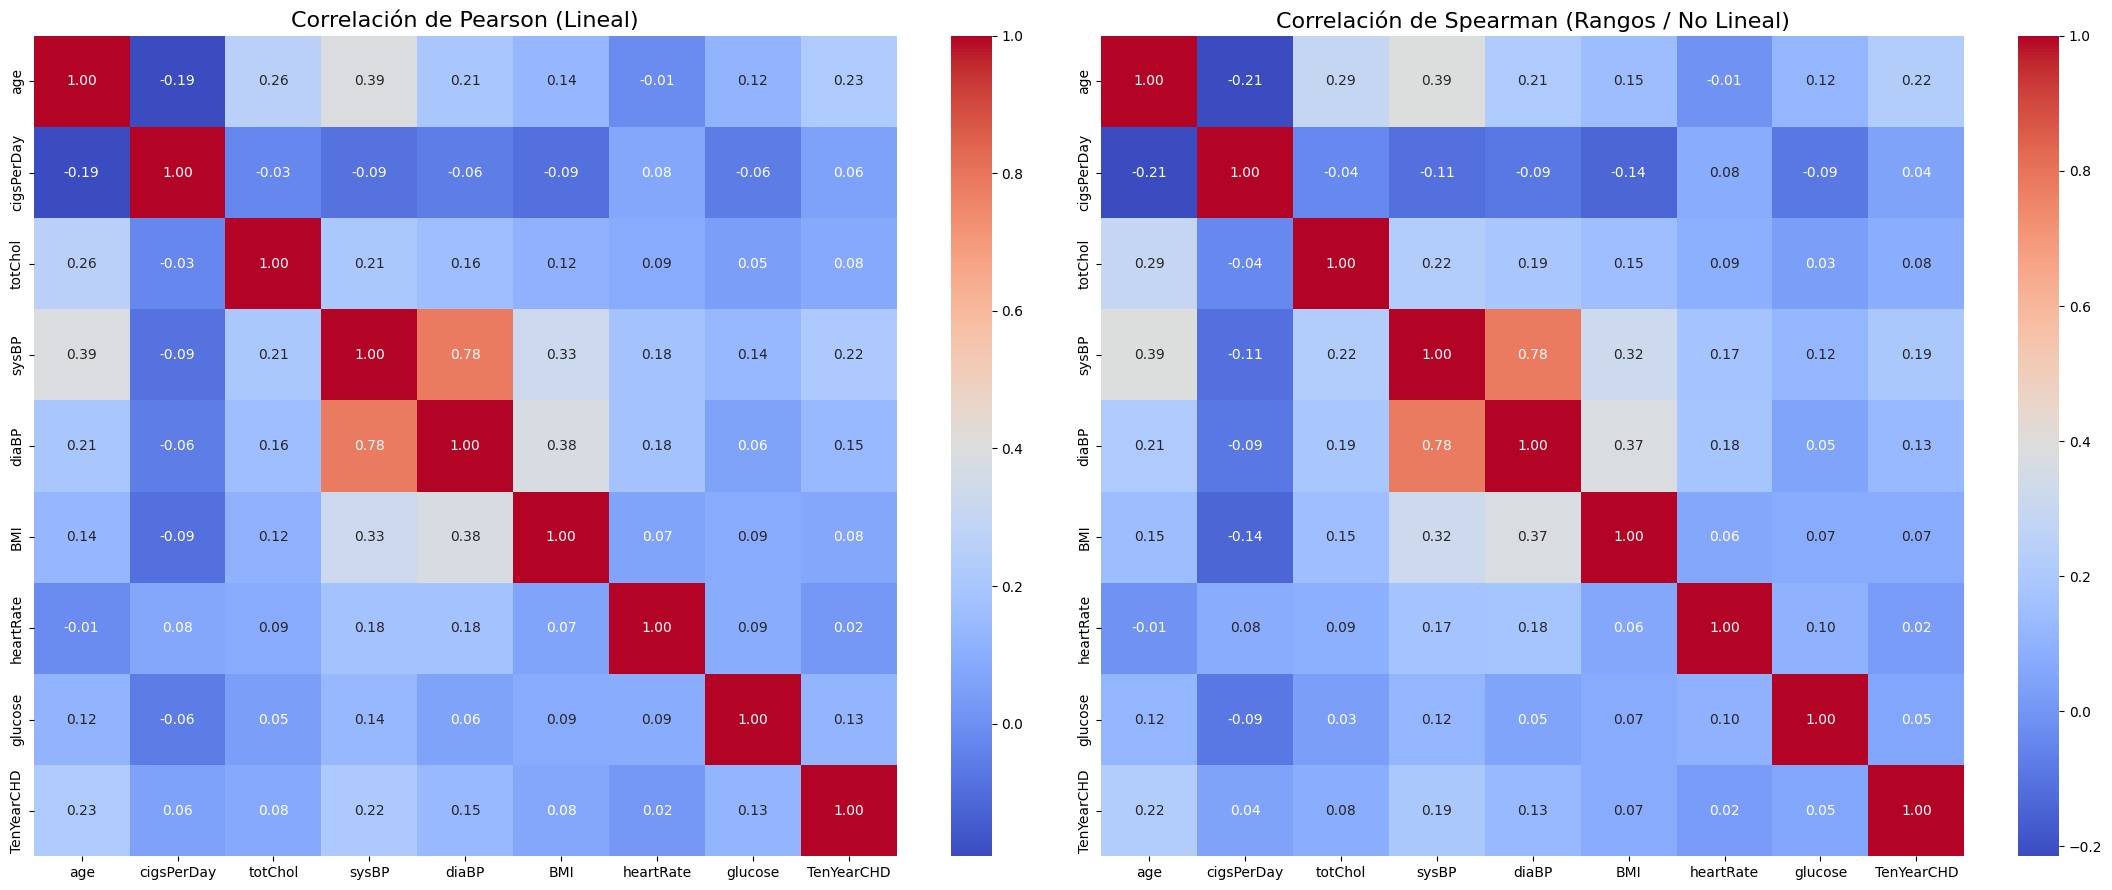

In [35]:
# 3. Configuramos la figura con dos subplots (uno al lado del otro)
fig, ax = plt.subplots(1, 2, figsize=(22, 9))

# Heatmap de Pearson
sns.heatmap(pearson_matrix, annot=True, fmt=".2f", cmap='coolwarm', ax=ax[0], cbar=True)
ax[0].set_title('Correlación de Pearson (Lineal)', fontsize=16)

# Heatmap de Spearman
sns.heatmap(spearman_matrix, annot=True, fmt=".2f", cmap='coolwarm', ax=ax[1], cbar=True)
ax[1].set_title('Correlación de Spearman (Rangos / No Lineal)', fontsize=16)

plt.tight_layout()
plt.show()

In [47]:
# 4. Bonus: Mostrar solo la relación con 'is_fraud' ordenada
print("--- Correlación de Spearman con el target ---")
print(spearman_matrix['TenYearCHD'].sort_values(ascending=False))

--- Correlación de Spearman con el target ---
TenYearCHD    1.000000
age           0.222953
sysBP         0.194375
diaBP         0.131501
totChol       0.080001
BMI           0.073680
glucose       0.054373
cigsPerDay    0.043478
heartRate     0.018009
Name: TenYearCHD, dtype: float64


In [46]:
# 4. Bonus: Mostrar solo la relación con 'is_fraud' ordenada
print("--- Correlación de Spearman con el target ---")
print(pearson_matrix['TenYearCHD'].sort_values(ascending=False))


--- Correlación de Spearman con el target ---
TenYearCHD    1.000000
age           0.225408
sysBP         0.216374
diaBP         0.145112
glucose       0.125590
totChol       0.082369
BMI           0.075300
cigsPerDay    0.057755
heartRate     0.022907
Name: TenYearCHD, dtype: float64


Observamos que no hay relaciones extremadamente fuertes, existen correlaciones débiles y medianas.

**Variables Categóricas**

In [45]:
resultados = []

print("--- Análisis de Chi-Cuadrado vs Target ---")

for col in str_cols:
    # Creamos la tabla de contingencia (frecuencias cruzadas)
    contingency_table = pd.crosstab(df[col], df['TenYearCHD'])
    
    # Calculamos Chi2 y el p-valor
    chi2, p, dof, ex = chi2_contingency(contingency_table)
    
    # Interpretación
    dependiente = "SÍ (Significativa)" if p < 0.05 else "NO (Independiente)"
    
    resultados.append({
        'Variable': col,
        'Chi2': round(chi2, 2),
        'p-valor': f"{p:.4e}", # Formato científico para p-valores muy pequeños
        'Relación con Fraude': dependiente
    })

# 2. Mostramos los resultados en una tabla limpia
df_chi = pd.DataFrame(resultados).sort_values(by='Chi2', ascending=False)
print(df_chi.to_string(index=False))

--- Análisis de Chi-Cuadrado vs Target ---
       Variable    Chi2    p-valor Relación con Fraude
     TenYearCHD 4232.24 0.0000e+00  SÍ (Significativa)
   prevalentHyp  132.46 1.1890e-30  SÍ (Significativa)
       diabetes   38.48 5.5251e-10  SÍ (Significativa)
           male   32.62 1.1215e-08  SÍ (Significativa)
      education   32.02 5.1904e-07  SÍ (Significativa)
         BPMeds   30.65 3.0967e-08  SÍ (Significativa)
prevalentStroke   14.03 1.7957e-04  SÍ (Significativa)
  currentSmoker    1.50 2.2110e-01  NO (Independiente)


observamos que todas las variables son significativas, excepto el current smoker

In [48]:
def cramers_v(contingency_table):
    """ Calcula el coeficiente V de Cramer para una tabla de contingencia. """
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    phi2 = chi2 / n
    r, k = contingency_table.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

resultados_v = []

print("--- Análisis de Fuerza de Asociación (V de Cramer) ---")

for col in str_cols:
    # Creamos la tabla de contingencia
    contingency_table = pd.crosstab(df[col], df['TenYearCHD'])
    
    # Calculamos V de Cramer
    v = cramers_v(contingency_table)
    
    # Interpretación rápida de la fuerza
    if v > 0.5: fuerza = "Muy Fuerte"
    elif v > 0.3: fuerza = "Fuerte"
    elif v > 0.1: fuerza = "Moderada"
    else: fuerza = "Débil"
    
    resultados_v.append({
        'Variable': col,
        'Cramers V': round(v, 4),
        'Fuerza': fuerza
    })

# Mostramos resultados ordenados por fuerza
df_v = pd.DataFrame(resultados_v).sort_values(by='Cramers V', ascending=False)
print(df_v.to_string(index=False))

--- Análisis de Fuerza de Asociación (V de Cramer) ---
       Variable  Cramers V     Fuerza
     TenYearCHD     0.9991 Muy Fuerte
   prevalentHyp     0.1761   Moderada
       diabetes     0.0940      Débil
           male     0.0864      Débil
         BPMeds     0.0842      Débil
      education     0.0838      Débil
prevalentStroke     0.0554      Débil
  currentSmoker     0.0108      Débil


aqui podemos ver que hay variables que son fuertes es moderada (prevalentHyp), y el resto son debiles (diabetes, male, BPMeds, education, prevalentStroke, current Smoker). Sin embargo, las últimas dos variables son tan débiles que incluso se podría plantear en eliminarse ya que no tienen una fuerte asociación con la target.